# Round 2 — Underscore Pattern EDA
Analyzes `_token_` disfluency markup in human translations.
Flags mismatched underscores and unusually long marked spans.

In [1]:
import re
import csv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

DATA = '../data/prolific_responses_filtered.csv'
sns.set_theme(style='whitegrid', font_scale=1.1)

In [2]:
df_raw = pd.read_csv(DATA)

# Keep only translation rows (questions that start with '[')
df = df_raw[df_raw['question'].str.startswith('[')].copy()

# Parse UID → language and annotator slot
df[['lang', 'slot']] = df['UID'].str.extract(r'^([A-Z]+)_(T\d)$')

# Parse utterance ID from question
df['utt_id'] = df['question'].str.extract(r'^\[([^\]]+)\]')

print(f'{len(df)} translation rows, {df["UID"].nunique()} forms, {df["lang"].nunique()} languages')
df.head(3)

620 translation rows, 31 forms, 8 languages


,UID,formId,responseId,timestamp,question,answer,lang,slot,utt_id
1,AR_T1,1TNZ4KNu1QaxqcQABHfeiDEUCUF2W57YHXYOE249FBdQ,ACYDBNgDIHgpffMHC3jdAB_l7VS-3htMrmBHtoJx1HPitf...,2026-04-02T02:58:15.787825Z,[sw02005_B_2] Translation 1,"_حسنا_, بالطبع, _إن_ _ه_ _, _ _أنت__تعلم _ _ إ...",AR,T1,sw02005_B_2
2,AR_T1,1TNZ4KNu1QaxqcQABHfeiDEUCUF2W57YHXYOE249FBdQ,ACYDBNgDIHgpffMHC3jdAB_l7VS-3htMrmBHtoJx1HPitf...,2026-04-02T02:58:15.787825Z,[sw02005_B_4] Translation 2,"سأكون جد جد حدر_ و_ _, _ _اه_ _, _ _كما_ _تعلم...",AR,T1,sw02005_B_4
3,AR_T1,1TNZ4KNu1QaxqcQABHfeiDEUCUF2W57YHXYOE249FBdQ,ACYDBNgDIHgpffMHC3jdAB_l7VS-3htMrmBHtoJx1HPitf...,2026-04-02T02:58:15.787825Z,[sw02005_B_8] Translation 3,"حسنا, كنت جد مرتاحا _, _ _كما_ _تعلم_ _, _في ا...",AR,T1,sw02005_B_8


## 1. Underscore count per translation

In [3]:
def count_underscores(text):
    """Count raw underscore characters (for display only)."""
    return str(text).count('_')

def extract_spans(text):
    """
    Extract all marked spans, handling both valid forms:
      _word_    — single-underscore wrap  (e.g. _, _  or  _uh_)
      __word__  — double-underscore wrap  (e.g. __blah__)

    Double-underscore patterns are stripped first so the inner
    single-underscore regex never partially matches them.
    """
    t = str(text)
    spans = []
    # 1. Capture __x__ spans
    spans += re.findall(r'__([^_]+)__', t)
    # 2. Remove __x__ tokens, then capture _x_ spans
    t2 = re.sub(r'__[^_]+__', '', t)
    spans += re.findall(r'_([^_]+)_', t2)
    return spans

def is_mismatched(text):
    """
    True only if underscores remain after stripping ALL valid spans.
    Both _, _  and  __blah__  are considered valid and are removed first.
    """
    t = str(text)
    t = re.sub(r'__[^_]+__', '', t)   # remove __x__ first
    t = re.sub(r'_[^_]+_',   '', t)   # then remove _x_
    return '_' in t

def longest_span(text):
    spans = extract_spans(text)
    return max((len(s) for s in spans), default=0)

def span_count(text):
    return len(extract_spans(text))

df['n_underscores']  = df['answer'].apply(count_underscores)
df['mismatched']     = df['answer'].apply(is_mismatched)
df['n_spans']        = df['answer'].apply(span_count)
df['longest_span']   = df['answer'].apply(longest_span)
df['answer_len']     = df['answer'].apply(lambda x: len(str(x)))

print('Mismatched underscore rows:', df['mismatched'].sum())
print('Total translations with any underscore:', (df['n_underscores'] > 0).sum())
print('Total translations with NO underscore:', (df['n_underscores'] == 0).sum())

# Quick sanity checks
assert not is_mismatched('hello _, _ world')       # _, _  is valid
assert not is_mismatched('hello __blah__ world')   # __x__ is valid
assert not is_mismatched('_uh_ and __yeah__')      # both together
assert     is_mismatched('_uh_ stray_')            # one leftover _
print('Sanity checks passed.')

Mismatched underscore rows: 121
Total translations with any underscore: 595
Total translations with NO underscore: 25
Sanity checks passed.


## 2. Mismatched underscore rows

In [4]:
mismatched_df = df[df['mismatched']].sort_values('n_underscores', ascending=False)
print(f'{len(mismatched_df)} mismatched rows')
pd.set_option('display.max_colwidth', 120)
mismatched_df[['UID', 'lang', 'utt_id', 'n_underscores', 'answer']].head(20)

121 mismatched rows


,UID,lang,utt_id,n_underscores,answer
658,ZH_T4,ZH,sw02027_A_79,109,_嗯_我不知道，我只是认为_，__你___知道__，_是的_，有时我担心_，__你___知道_，_如果我穿裤子进去，_我__从来_，_我从来没有，我从来从来从来没有穿牛仔裤_，__你__知道_。但我会穿着裤子进去。_我__我的意思是...
537,IT_T3,IT,sw02015_B_18,99,"_ah-ah_ _, _ _ah-ah_ _. _ _si_ _, _ questo è vero. vivere in un complesso di appartamenti però _ _tu_ _sai_ _tu_ _no..."
462,HI_T3,HI,sw02020_B_104,97,"_खैर_ _, _ _आप_ _जानते_ _हैं_ _, _ वास्तव में वह विश्व संगीत नहीं है। लेकिन, _क्या_ _, _ जो पॉल साइमन कर रहा है _, _..."
281,ES_T3,ES,sw02015_B_18,91,"_Uh-huh__, __uh-huh__. __SI__, _ eso es verdad. Sin embargo al vivir en un departamento_, __tu__ sabes__ que no__, _..."
81,CS_T1,CS,sw02005_A_147,91,"_Jo_ _. _ Ale, _ach_, _já_ _, _ _já_ _, _ já myslím že _, _ _ty_ _víš_ _, _ _my_ _vždycky_ _, _ _ach_ _, _ _já_ _mys..."
451,HI_T3,HI,sw02015_B_20,85,"_हाँ_ _, _ _हाँ_ _, _ _नहीं_ _, _ _मैं_ _, _ मैं वहाँ आपसे सहमत हूँ। यदि वे उस विशेष धर्म का चयन करना चाहते हैं तो व..."
378,FR_T3,FR,sw02020_B_104,81,"_Bon_ _, _ _vous_ _savez_ _, _ vraiment ce n'est pas de la musique du monde. Mais, _ce_ _, _ ce que fait Paul Simon ..."
293,ES_T3,ES,sw02020_B_104,79,"_Bueno_ _, _ _ya_ _sabes_ _, _ realmente eso no es musica mundial. Pero, _lo que_ _, _lo que Paul Simon está haciend..."
594,ZH_T1,ZH,sw02005_A_147,79,_是啊_ _。_ 但，_呃_， _我_ _，_ _我_ _，_ 我觉得_，_ _你知道_ _，_ _我们_ _总是_ _，_ _呃_ _，_ _我是说_ _，_ _我_ _曾_ _，_ 我和很多人都有过很多美好的经历_，_ _呃_，...
298,ES_T3,ES,sw02022_B_18,73,"_Si_ _, _ _si_ _, _ _yo_ _me mantengo_ _den-_ _, _ me tengo que mantener dentro de el, asi _, _ _ya_ _sabes_, y desp..."


## 3. Long spans — potential over-marking

In [5]:
LONG_SPAN_THRESHOLD = 30  # characters

def long_spans(text, threshold=LONG_SPAN_THRESHOLD):
    return [s for s in extract_spans(text) if len(s) >= threshold]

df['long_spans'] = df['answer'].apply(long_spans)
df['has_long_span'] = df['long_spans'].apply(bool)

long_df = df[df['has_long_span']].sort_values('longest_span', ascending=False)
print(f'{len(long_df)} rows with a span ≥ {LONG_SPAN_THRESHOLD} chars')
long_df[['UID', 'lang', 'utt_id', 'longest_span', 'long_spans', 'answer']].head(20)

73 rows with a span ≥ 30 chars


,UID,lang,utt_id,longest_span,long_spans,answer
354,FR_T2,FR,sw02012_A_25,400,"[ je ne connais pas les théories du complot de la CIA ou peu importe, auraient de telles organisations qui essaierai...","Bon, vraisemblablement, ceux qui découvrent ce genre d’informations, s’ils le font, je préférerais qu’on ne le sache..."
34,AR_T2,AR,sw02012_A_25,319,[ أنا لا أعرف نظريات المؤامرة الخاصة بـ وكالة الاستخبارات المركزية(CIA) أو أي شيء من هذا القبيل، سيكون لديهم مثل هذه...,_حسنًا_، من المفترض أن أولئك الذين يكتشفون مثل هذه المعلومات، إذا كانوا يفعلون ذلك، أفضل ألا أعرف، و _،_ أنا أعني_،_...
524,IT_T2,IT,sw02012_A_25,304,"[ complotti della CIA o altro, avrebbero attori che cercano di farlo senza che tu lo sappia. Quindi ci sono cose che...","_Beh_, presumibilmente coloro che scoprono questa informazione, se lo stanno facendo, preferirei _non_ non si sapess..."
537,IT_T3,IT,sw02015_B_18,167,"[, non puoi veramente fermare queste persone dal venire intorno, anche se loro mettono cartelli che dicono non distu...","_ah-ah_ _, _ _ah-ah_ _. _ _si_ _, _ questo è vero. vivere in un complesso di appartamenti però _ _tu_ _sai_ _tu_ _no..."
279,ES_T3,ES,sw02012_A_99,166,"[oo Mormones o alguien golpeando la puerta principal, , , que es más intrusivo porque realmente le tengo que pedir a...","Todos _los __ clási__, _los otros ejemplos clásicos, el Testigo de Jehova _o__. __o Mormones o alguien golpeando la ..."
324,FR_T1,FR,sw02005_B_8,166,"[, elle ne pouvait plus prendre soins d'elle maintenant, elle a été enfermer dans une maison de soins pour un moment...","Donc, j'etais vraiment confortable, _tu sais_, a le faire au point on devais le faire. Mais il y a,_enfin_, j'ai eu ..."
450,HI_T3,HI,sw02015_B_18,154,"[, और वे कुछ बेचने की कोशिश कर रहे हैं , या वे किसी धार्मिक संगठन से हैं और मैं उससे सचमें नफरत करता हूँ। मैं वास्त...","_उह-हूह_ _, _ _उह-हूह_ _। _ _हाँ_ _, _ यह सच है। एक अपार्टमेंट कॉम्प्लेक्स में रहना, हालांकि _आप_ _जानते_ _हैं_ _आप_..."
535,IT_T3,IT,sw02012_A_99,146,"[ l'altro esempio classico, il testimone di Geova , oppure i mormoni o qualcuno che bussa alla porta di casa, , ch...","Tutte_le_classi-_ _, _ l'altro esempio classico, il testimone di Geova _oppure_ _, _ oppure i mormoni o qualcuno che..."
361,FR_T2,FR,sw02012_A_87,142,"[, comportement public. Euh, les gens commencent à faire attention à toi beaucoup et ils commencent à poser des ques...","Alors que dans ce pays où tout le monde respecte les portes fermées beaucoup, si tu sors et ensuite agis comme le fo..."
230,DE_T4,DE,sw02028_A_125,134,"[, ich bin eigentlich nur in der Luftabteilung und wir beobachten, , alles was aus einem Schornstein kommt oder aus...","_Sich_, _sich kümmern um _ähm_, ich bin eigentlich nur in der Luftabteilung und wir beobachten, _ähm_ alles was aus ..."


## 4. Plots

/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_19159/1097150477.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  usage = df.groupby('lang').apply(lambda g: (g['n_underscores'] > 0).mean() * 100)


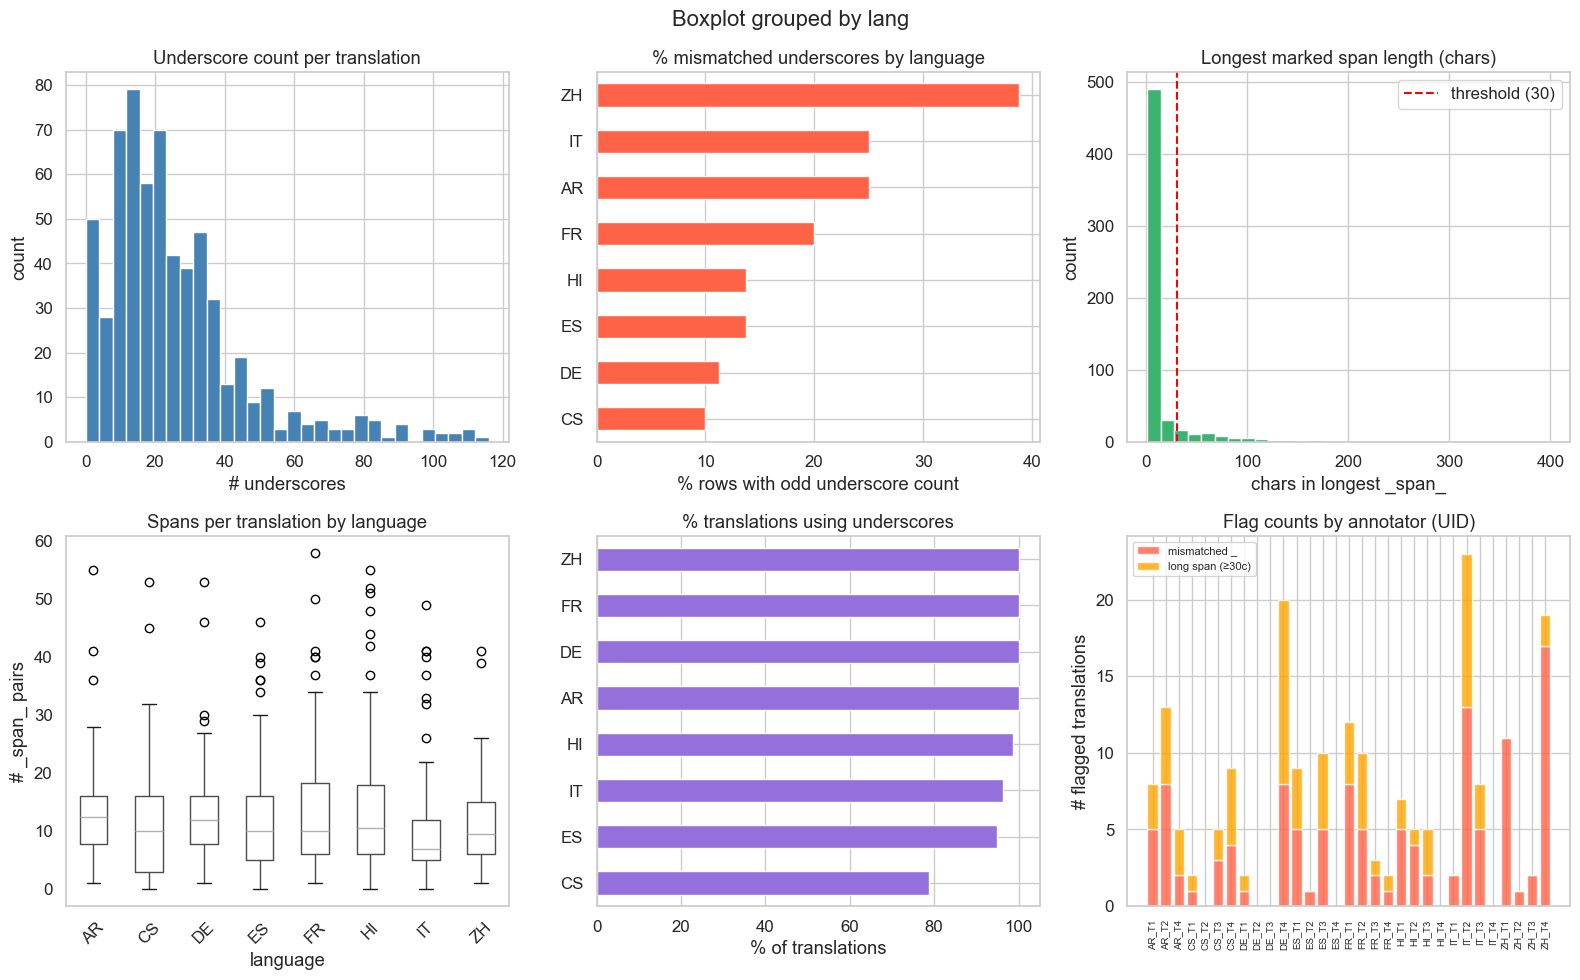

Saved → underscore_eda.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Round 2 Underscore Pattern EDA', fontsize=14, fontweight='bold')

# --- 4a. Underscore count distribution ---
ax = axes[0, 0]
ax.hist(df['n_underscores'], bins=30, color='steelblue', edgecolor='white')
ax.set_title('Underscore count per translation')
ax.set_xlabel('# underscores')
ax.set_ylabel('count')

# --- 4b. Mismatched vs matched by language ---
ax = axes[0, 1]
mismatch_by_lang = df.groupby('lang')['mismatched'].agg(['sum', 'count'])
mismatch_by_lang['pct'] = mismatch_by_lang['sum'] / mismatch_by_lang['count'] * 100
mismatch_by_lang['pct'].sort_values().plot.barh(ax=ax, color='tomato')
ax.set_title('% mismatched underscores by language')
ax.set_xlabel('% rows with odd underscore count')
ax.set_ylabel('')

# --- 4c. Longest span distribution ---
ax = axes[0, 2]
ax.hist(df[df['longest_span'] > 0]['longest_span'], bins=30, color='mediumseagreen', edgecolor='white')
ax.axvline(LONG_SPAN_THRESHOLD, color='red', linestyle='--', label=f'threshold ({LONG_SPAN_THRESHOLD})')
ax.set_title('Longest marked span length (chars)')
ax.set_xlabel('chars in longest _span_')
ax.set_ylabel('count')
ax.legend()

# --- 4d. Spans per translation by language ---
ax = axes[1, 0]
df.boxplot(column='n_spans', by='lang', ax=ax, grid=False)
ax.set_title('Spans per translation by language')
ax.set_xlabel('language')
ax.set_ylabel('# _span_ pairs')
plt.sca(ax); plt.xticks(rotation=45)

# --- 4e. % translations with any underscore by language ---
ax = axes[1, 1]
usage = df.groupby('lang').apply(lambda g: (g['n_underscores'] > 0).mean() * 100)
usage.sort_values().plot.barh(ax=ax, color='mediumpurple')
ax.set_title('% translations using underscores')
ax.set_xlabel('% of translations')
ax.set_ylabel('')

# --- 4f. Flag map: mismatched + long span by UID ---
ax = axes[1, 2]
flag_by_uid = df.groupby('UID').agg(
    mismatched=('mismatched', 'sum'),
    long_span=('has_long_span', 'sum'),
    total=('mismatched', 'count')
).reset_index()
flag_by_uid = flag_by_uid.sort_values('UID')
x = range(len(flag_by_uid))
ax.bar(x, flag_by_uid['mismatched'], label='mismatched _', color='tomato', alpha=0.8)
ax.bar(x, flag_by_uid['long_span'],  bottom=flag_by_uid['mismatched'], label=f'long span (≥{LONG_SPAN_THRESHOLD}c)', color='orange', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(flag_by_uid['UID'], rotation=90, fontsize=7)
ax.set_title('Flag counts by annotator (UID)')
ax.set_ylabel('# flagged translations')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('underscore_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → underscore_eda.png')

## 5. Summary table — flagged translations

In [7]:
flagged = df[df['mismatched'] | df['has_long_span']].copy()
flagged['flags'] = flagged.apply(
    lambda r: ', '.join(filter(None, [
        'mismatched_underscore' if r['mismatched'] else '',
        f'long_span({r["longest_span"]}c)' if r['has_long_span'] else ''
    ])), axis=1
)
print(f'{len(flagged)} total flagged translations')
flagged[['UID', 'lang', 'utt_id', 'flags', 'n_underscores', 'longest_span', 'answer']]\
    .sort_values(['lang', 'UID', 'utt_id'])\
    .reset_index(drop=True)

140 total flagged translations


,UID,lang,utt_id,flags,n_underscores,longest_span,answer
0,AR_T1,AR,sw02005_A_19,long_span(38c),24,38,"_اووه_ _. _ _نعم_ _. _ من الممكن أصعب شيئ_ في_ _, عائلتي ,_اه_, جدتي , إضطرت لتوضع بدار العناية و , _امم_ , اضطرت لإ..."
1,AR_T1,AR,sw02005_A_65,mismatched_underscore,37,4,"_حسنا_ _, _ حسنا ,_أنا_ _أقصد_ _, _دلك, _أنا_ _أقصد_ _, _ _أنا_ _, _ _أ نا_ _, _ _أنا_ _, _ _أنا_ _هار-_ _, _ _أنا_ ..."
2,AR_T1,AR,sw02005_A_81,mismatched_underscore,29,5,"_نعم_ _. _ _نعم_ _. _ _حسنا_, _مع_ _مي_ _, _ مع جدتي _أ_ _أعتقد_ _قد_ _كان_ -, كان ك _أنه_ _, _ اه_,أنها لم يكن لديه..."
3,AR_T1,AR,sw02005_B_14,"mismatched_underscore, long_span(35c)",31,35,"_كما_ _تعلم_ _, _ هل هناك شيء آخر من الممكن فعله _,_ _كما_ _تعلم_ _, في التحقق من جميع الأماكن التي , _اه_, من الممك..."
4,AR_T1,AR,sw02005_B_2,"mismatched_underscore, long_span(36c)",57,36,"_حسنا_, بالطبع, _إن_ _ه_ _, _ _أنت__تعلم _ _ إنه أحد آخر الأشياء التي تود فعلها _, _ _كما_ _تعلم_ _. _ إلا إنه فقط _..."
...,...,...,...,...,...,...,...
135,ZH_T4,ZH,sw02028_A_125,mismatched_underscore,17,1,管__，_管理_呃_，我實際上在航空部门里面我們監控，_嗯_，任何從堆中或建築物中出來的東西，或者，_嗯_，我們確實有客户，_嗯_，他們的擔憂是在工作場所，我们会处理的，但是仅有在我們的部門。 我们将处理一切。 废水，_呃_，废物，...
136,ZH_T4,ZH,sw02028_A_147,mismatched_underscore,30,7,而且，_呃_，_我们的__，_我们的化学数据库，这样我们就可以知道在那个地方的每一种化学物质_和_和_，_嗯_，其浓度，以及_如果__，_如果发生任何事情_，__上帝_真的希望不会__，_你___知道_，_建筑物爆炸或__，_我们将...
137,ZH_T4,ZH,sw02032_A_135,mismatched_underscore,32,2,所以，就像，七十年代什么都没发生。一切都发生在六十年代，七十年代我不知道它们叫什麼_，_ _你___知道_，它_像__，_像___，_八十年代被称为，_像_进步年，_或____或_，_你___知道_，___像_科技年代，因为所有的电...
138,ZH_T4,ZH,sw02032_A_39,mismatched_underscore,10,2,但是，_看_，例如，他们有，_看_什么，但其他乐队认为它_像_真正的硬摇滚。这就像重金属音乐，他们所做的只是_相似_，他们有这把吉他，他们只是敲打吉他，吉他是__，真设置的很低，
